# Project M2 – Individual Initial Analysis  
## Temporal Activity and Speed-Based Clustering of Pet Cats in the UK
## - B1 Team 12
## - Xiaoyan Wang


#Summary of the proposal Q2

###Q2: How do cats form distinct clusters when analyzed by time period and ground speed using unsupervised methods?


Insights: The EDA results show that cats exhibit particularly high activity levels during nighttime hours, especially around 11 PM and 12 AM. Analyzing temporal activity patterns provides deeper insight into cats’ living habits and behavioral dynamics.


Significance: Understanding cats’ daily activity patterns helps researchers examine behavioral traits and environmental influences, while enabling city governments to develop targeted, time-based strategies to reduce animal-related damage and improve urban coexistence.

###Data Import

In [35]:
import pandas as pd
import numpy as np

cats_gps_url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-01-31/cats_uk.csv"
cats_meta_url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-01-31/cats_uk_reference.csv"
cats_gps = pd.read_csv(cats_gps_url)
cats_meta = pd.read_csv(cats_meta_url)
print("GPS dataset shape:", cats_gps.shape)
print("Metadata dataset shape:", cats_meta.shape)

cats_gps.head(), cats_meta.head()


GPS dataset shape: (18215, 11)
Metadata dataset shape: (101, 16)


(  tag_id    event_id  visible             timestamp  location_long  \
 0   Ares  3395610551     True  2017-06-24T01:03:57Z      -5.113851   
 1   Ares  3395610552     True  2017-06-24T01:11:20Z      -5.113851   
 2   Ares  3395610553     True  2017-06-24T02:58:16Z      -5.113730   
 3   Ares  3395610554     True  2017-06-24T03:01:26Z      -5.113774   
 4   Ares  3395610555     True  2017-06-24T03:51:58Z      -5.114247   
 
    location_lat  ground_speed  height_above_ellipsoid  \
 0     50.170315           684                  154.67   
 1     50.170315           936                  154.67   
 2     50.169876          2340                   81.35   
 3     50.169827             0                   67.82   
 4     50.170139          4896                  118.03   
 
    algorithm_marked_outlier  manually_marked_outlier               study_name  
 0                     False                    False  Pet Cats United Kingdom  
 1                     False                    False  Pet C

## Preparation

After loading the GPS movement data and the cat-level metadata, the next step is to prepare the data for unsupervised clustering. Since the research question focuses on temporal activity patterns and movement speed, the analysis shifts from individual GPS records to summarized behavioral features at the cat level.

In this section, I clean the GPS data by removing invalid and outlier observations, extract time-of-day information from timestamps, and define simple indicators for night-time activity. The cleaned data are then aggregated so that each row represents one cat, with features capturing average movement speed and the proportion of night-time activity. These features will serve as the input for K-means clustering in the following steps.


In [36]:
cats_gps["timestamp"] = pd.to_datetime(
    cats_gps["timestamp"],
    errors="coerce",
    utc=True
)

cats_gps = cats_gps.dropna(subset=["tag_id", "timestamp"])

cats_gps["hour"] = cats_gps["timestamp"].dt.hour

cats_gps[["timestamp", "hour"]].head()



,timestamp,hour
0,2017-06-24 01:03:57+00:00,1
1,2017-06-24 01:11:20+00:00,1
2,2017-06-24 02:58:16+00:00,2
3,2017-06-24 03:01:26+00:00,3
4,2017-06-24 03:51:58+00:00,3


### Creating a Night-Time Activity Indicator
1 = night, 0 = day

In [37]:
night_hours = [20, 21, 22, 23, 0, 1, 2, 3, 4, 5]
cats_gps["is_night"] = cats_gps["hour"].isin(night_hours).astype(int)

cats_gps["is_night"].value_counts()


,count
is_night,
1,9501
0,8714


## Preparing Ground Speed for Analysis

Before clustering, I need to make sure that the movement speed values are numeric and usable.
Any missing or invalid speed values are removed so that they do not affect the clustering results.


In [38]:
cats_gps["ground_speed"] = pd.to_numeric(
    cats_gps["ground_speed"],
    errors="coerce"
)

cats_gps = cats_gps.dropna(subset=["ground_speed"])

cats_gps["ground_speed"].describe()


,ground_speed
count,18215.000000
mean,1911.484381
std,4592.574178
min,0.000000
25%,396.000000
50%,1080.000000
75%,2232.000000
max,277092.000000


## Aggregating GPS Records to Cat-Level Features

The clustering analysis focuses on differences between individual cats rather than individual GPS records.
Therefore, I aggregate the cleaned GPS data so that each row represents one cat.

In [39]:
cat_features = cats_gps.groupby("tag_id").agg(
    n_points=("ground_speed", "count"),
    mean_speed=("ground_speed", "mean"),
    median_speed=("ground_speed", "median"),
    night_ratio=("is_night", "mean")
)

cat_features.head()


,n_points,mean_speed,median_speed,night_ratio
tag_id,,,,
Abba-Tag,83,1603.951807,864.0,0.614458
Alfie-Tag,187,1931.679144,1188.0,0.481283
Amber-Tag,218,1967.614679,1188.0,0.188073
Ares,103,2285.825243,1440.0,0.718447
Athena,106,2134.188679,1494.0,0.490566


## Preparing Features for K-means Clustering

-Select features for K-means

In [40]:
X = cat_features[[
    "mean_speed",
    "median_speed",
    "night_ratio"
]]

X.head()


,mean_speed,median_speed,night_ratio
tag_id,,,
Abba-Tag,1603.951807,864.0,0.614458
Alfie-Tag,1931.679144,1188.0,0.481283
Amber-Tag,1967.614679,1188.0,0.188073
Ares,2285.825243,1440.0,0.718447
Athena,2134.188679,1494.0,0.490566


-Standardize features

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape of data for K-means:", X_scaled.shape)


Shape of data for K-means: (101, 3)


## Choosing the Number of Clusters


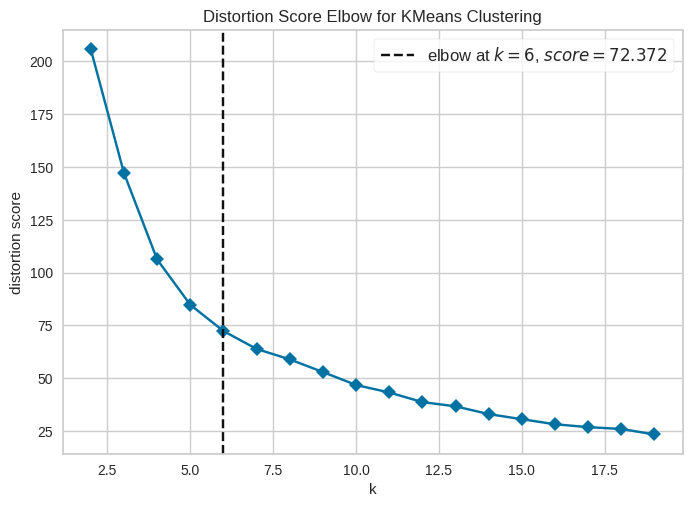

Elbow K suggested by visualizer: 6


In [42]:
!pip -q install yellowbrick

from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

clustering = KMeans(random_state=42)

visualizer = KElbowVisualizer(
    clustering,
    k=(2, 20),
    metric="distortion",
    timings=False
)

visualizer.fit(X_scaled)
visualizer.show()

print("Elbow K suggested by visualizer:", visualizer.elbow_value_)


## Choosing the Number of Clusters

To support the choice of K, I briefly examined the elbow plot and selected K = 6, since the curve begins to flatten around this point and additional clusters provide smaller improvements.


In [43]:
from sklearn.cluster import KMeans

k = 6

kmeans = KMeans(n_clusters=k, random_state=42)

cat_features["cluster"] = kmeans.fit_predict(X_scaled)

cat_features.head()


,n_points,mean_speed,median_speed,night_ratio,cluster
tag_id,,,,,
Abba-Tag,83,1603.951807,864.0,0.614458,0
Alfie-Tag,187,1931.679144,1188.0,0.481283,1
Amber-Tag,218,1967.614679,1188.0,0.188073,5
Ares,103,2285.825243,1440.0,0.718447,2
Athena,106,2134.188679,1494.0,0.490566,1


In [44]:
cats_cluster = cats_gps[["hour", "ground_speed"]].dropna().copy()
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cats_cluster[["hour", "ground_speed"]])
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=6, random_state=42)
cats_cluster["cluster"] = kmeans.fit_predict(X_scaled)
cats_cluster.head()
cats_cluster["cluster"].value_counts()



,count
cluster,
4,7105
3,5281
2,4714
0,928
5,180
1,7


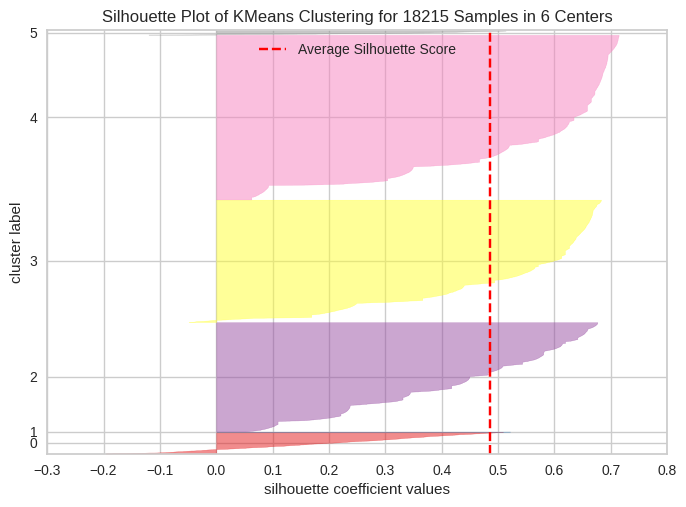

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 18215 Samples in 6 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [45]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import SilhouetteVisualizer

kmeans_model = KMeans(n_clusters=6, random_state=42)

visualizer = SilhouetteVisualizer(kmeans_model, timings=False)

visualizer.fit(X_scaled)
visualizer.show()


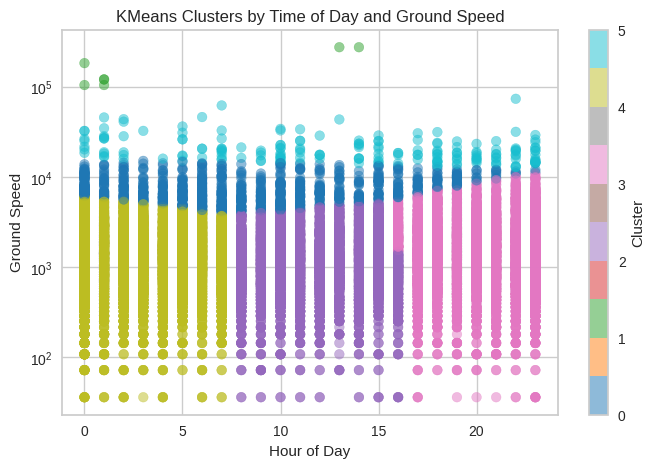

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(
    cats_cluster["hour"],
    cats_cluster["ground_speed"],
    c=cats_cluster["cluster"],
    cmap="tab10",
    alpha=0.5
)

plt.xlabel("Hour of Day")
plt.ylabel("Ground Speed")
plt.title("KMeans Clusters by Time of Day and Ground Speed")
plt.colorbar(label="Cluster")
plt.yscale("log")
plt.show()


Before running the clustering, I expected the observations to form more clearly separated groups based on speed. However, I am not sure whether this separation would still hold once night activity was included.


## Running K-means with K = 6

Based on the elbow plot, I selected K = 6 as the number of clusters, since the distortion score begins to flatten around this point and additional clusters lead to smaller improvements.

I then applied K-means clustering to the standardized cat-level features. Each cat was assigned to one of the seven clusters, and the resulting cluster label was added to the dataset for further analysis.


## Understanding Cluster Characteristics

In [47]:
cluster_summary = (
    cat_features
    .groupby("cluster")[["mean_speed", "median_speed", "night_ratio"]]
    .mean()
)

cluster_summary


,mean_speed,median_speed,night_ratio
cluster,,,
0,1573.370718,957.600000,0.574124
1,2228.716925,1279.565217,0.436010
2,2720.742280,1527.545455,0.646491
3,5052.000000,3420.000000,0.583333
4,1749.957301,1112.000000,0.775024
5,1549.623674,924.000000,0.259490


In [48]:
cluster_summary = (
    cat_features
    .groupby("cluster")[["mean_speed", "median_speed", "night_ratio"]]
    .mean()
)

cluster_summary


,mean_speed,median_speed,night_ratio
cluster,,,
0,1573.370718,957.600000,0.574124
1,2228.716925,1279.565217,0.436010
2,2720.742280,1527.545455,0.646491
3,5052.000000,3420.000000,0.583333
4,1749.957301,1112.000000,0.775024
5,1549.623674,924.000000,0.259490



After looking at the cluster summaries, the differences between clusters are easier to see in average values than at the individual level, and the separation is not as clear as I initially expected.

## Summary

This notebook was completed individually. I used k-means clustering to group observations based on mean speed, median speed, and night activity ratio.

After assigning cluster labels, I compared the clusters using simple average values. The results show that some clusters move faster on average, while others differ more in how much activity happens at night.

At the same time, the cluster boundaries are not very clear, and many observations still look similar across clusters. This means the results are better viewed as a rough first pass, not a final answer.

## Next Steps

From the cluster summary, the clusters mainly differ in speed levels and night activity ratios. While these differences are visible at the average level, it is still unclear how consistent the patterns are within each cluster.

Next, it would be helpful to look more closely at the distribution of observations inside each cluster, rather than only comparing mean values. This can help check whether the differences come from general behavior or just a small number of extreme cases.

It would also be useful to see if these clusters relate to any other available information, so we can better understand whether they represent meaningful usage patterns instead of only statistical groupings.

Finally, trying different numbers of clusters or slightly different feature sets can help confirm whether the current patterns are stable.

## AI Disclosure

•	Coding(part)

•	Text Revision

•	Grammar Check

•	Formatting

ChatGPT chats: https://chatgpt.com/share/6988da93-590c-8010-a658-03333baf62ed

